In [1]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

In [2]:
file_path = "/content/drive/MyDrive/Colab Notebooks/Multimodal - G. Project/Indoor Fire Dataset with Distributed Multi-Sensor Nodes.csv"

In [3]:
fire_df = pd.read_csv(file_path)
fire_df.head()

,Date,Sensor_ID,CO2_Room,CO_Room,H2_Room,Humidity_Room,PM05_Room,PM100_Room,PM10_Room,PM25_Room,PM40_Room,PM_Room_Typical_Size,PM_Total_Room,Temperature_Room,UV_Room,VOC_Room_RAW,scenario_label,anomaly_label,ternary_label
0,2022-07-04 14:10:54.259355+00:00,Sensorknoten0009,1150.0,-0.43,0.13,51.50,15.0,0.0,2.0,0.0,0.0,0.40,17.0,26.3,0.0,0.5,Background,Normal,Background
1,2022-07-04 14:10:54.401380+00:00,Sensorknoten0015,1300.0,-0.08,0.12,52.85,7.0,0.0,0.0,0.0,0.0,0.45,8.0,25.7,0.0,0.5,Background,Normal,Background
2,2022-07-04 14:10:55.401182+00:00,Sensorknoten0011,412.0,-0.08,0.22,50.60,16.0,0.0,2.0,0.0,0.0,0.47,19.0,26.5,0.0,0.5,Background,Normal,Background
3,2022-07-04 14:10:55.899093+00:00,Sensorknoten0012,1100.0,-0.16,0.13,52.66,13.0,0.0,1.0,0.0,0.0,0.42,15.0,25.9,0.0,0.6,Background,Normal,Background
4,2022-07-04 14:10:59.346954+00:00,Sensorknoten0016,1392.0,0.18,0.09,52.53,10.0,0.0,1.0,0.0,0.0,0.44,11.0,26.0,0.0,0.5,Background,Normal,Background


In [4]:
fire_df[3627:3637]

,Date,Sensor_ID,CO2_Room,CO_Room,H2_Room,Humidity_Room,PM05_Room,PM100_Room,PM10_Room,PM25_Room,PM40_Room,PM_Room_Typical_Size,PM_Total_Room,Temperature_Room,UV_Room,VOC_Room_RAW,scenario_label,anomaly_label,ternary_label
3627,2022-07-04 15:18:06.083271+00:00,Sensorknoten0009,958.0,-0.29,0.21,51.49,15.0,0.0,2.0,0.0,0.0,0.43,18.0,26.3,0.0,0.7,Background,Normal,Background
3628,2022-07-04 15:18:06.202173+00:00,Sensorknoten0015,1450.0,-0.03,0.28,53.55,10.0,0.0,1.0,0.0,0.0,0.41,12.0,25.5,0.0,0.7,Background,Normal,Background
3629,2022-07-04 15:18:06.316013+00:00,Sensorknoten0011,1067.0,0.15,0.46,51.25,11.0,0.0,1.0,0.0,0.0,0.42,13.0,26.4,0.0,0.7,Background,Normal,Background
3630,2022-07-04 15:18:06.556938+00:00,Sensorknoten0012,1191.0,-0.04,0.31,53.57,16.0,0.0,2.0,0.0,0.0,0.42,19.0,25.7,0.0,0.7,Wood,Anomaly,Fire
3631,2022-07-04 15:18:09.277256+00:00,Sensorknoten0016,1584.0,0.05,0.25,53.56,9.0,0.0,1.0,0.0,0.0,0.39,10.0,25.8,0.0,0.7,Wood,Anomaly,Fire
3632,2022-07-04 15:18:12.055571+00:00,Sensorknoten0014,1423.0,0.41,0.17,55.32,27.0,0.0,3.0,0.0,0.0,0.42,31.0,25.0,0.0,0.8,Wood,Anomaly,Fire
3633,2022-07-04 15:18:12.223678+00:00,Sensorknoten0013,1314.0,0.12,0.29,55.49,21.0,0.0,3.0,0.0,0.0,0.39,24.0,25.0,0.0,0.7,Wood,Anomaly,Fire
3634,2022-07-04 15:18:13.168870+00:00,Sensorknoten0008,1283.0,-0.47,0.15,53.10,21.0,0.0,3.0,0.0,0.0,0.44,24.0,25.9,0.0,0.7,Wood,Anomaly,Fire
3635,2022-07-04 15:18:14.023620+00:00,Sensorknoten0010,1420.0,0.38,0.24,53.25,16.0,0.0,2.0,0.0,0.0,0.44,18.0,26.0,0.0,0.8,Wood,Anomaly,Fire
3636,2022-07-04 15:18:14.190959+00:00,Sensorknoten0009,772.0,-0.31,0.25,51.58,13.0,0.0,1.0,0.0,0.0,0.43,15.0,26.3,0.0,0.7,Wood,Anomaly,Fire


In [5]:
fire_df[77937:77947]

,Date,Sensor_ID,CO2_Room,CO_Room,H2_Room,Humidity_Room,PM05_Room,PM100_Room,PM10_Room,PM25_Room,PM40_Room,PM_Room_Typical_Size,PM_Total_Room,Temperature_Room,UV_Room,VOC_Room_RAW,scenario_label,anomaly_label,ternary_label
77937,2022-07-05 14:14:12.858115+00:00,Sensorknoten0010,794.0,0.17,0.03,40.16,6.0,0.0,0.0,0.0,0.0,0.40,7.0,25.9,0.0,1.1,Background,Normal,Background
77938,2022-07-05 14:14:13.063416+00:00,Sensorknoten0009,631.0,-0.90,0.10,38.61,6.0,0.0,0.0,0.0,0.0,0.44,7.0,26.4,0.0,1.1,Background,Normal,Background
77939,2022-07-05 14:14:13.250750+00:00,Sensorknoten0015,837.0,0.09,0.04,40.75,8.0,0.0,1.0,0.0,0.0,0.44,9.0,25.3,0.0,1.2,Background,Normal,Background
77940,2022-07-05 14:14:14.265637+00:00,Sensorknoten0012,606.0,-0.06,0.03,40.19,4.0,0.0,0.0,0.0,0.0,0.43,5.0,25.7,0.0,1.2,Ethanol,Anomaly,Nuisance
77941,2022-07-05 14:14:14.480465+00:00,Sensorknoten0011,565.0,-0.09,-0.14,38.61,5.0,0.0,0.0,0.0,0.0,0.40,6.0,26.3,0.0,1.0,Ethanol,Anomaly,Nuisance
77942,2022-07-05 14:14:17.660673+00:00,Sensorknoten0016,939.0,0.19,0.15,40.82,3.0,0.0,0.0,0.0,0.0,0.43,4.0,25.7,0.0,1.2,Ethanol,Anomaly,Nuisance
77943,2022-07-05 14:14:20.782498+00:00,Sensorknoten0014,716.0,-0.59,-0.07,41.18,8.0,0.0,1.0,0.0,0.0,0.40,10.0,25.0,0.0,0.9,Ethanol,Anomaly,Nuisance
77944,2022-07-05 14:14:20.943906+00:00,Sensorknoten0013,756.0,0.00,0.07,41.49,8.0,0.0,1.0,0.0,0.0,0.39,9.0,24.9,0.0,1.1,Ethanol,Anomaly,Nuisance
77945,2022-07-05 14:14:22.215908+00:00,Sensorknoten0008,675.0,-0.45,-0.20,40.45,7.0,0.0,1.0,0.0,0.0,0.43,9.0,25.7,0.0,1.5,Ethanol,Anomaly,Nuisance
77946,2022-07-05 14:14:22.874556+00:00,Sensorknoten0010,786.0,0.14,0.04,40.17,7.0,0.0,0.0,0.0,0.0,0.40,8.0,25.9,0.0,1.1,Ethanol,Anomaly,Nuisance


In [6]:
fire_df.shape

(305304, 19)

In [7]:
fire_df.isnull().sum()

,0
Date,0
Sensor_ID,0
CO2_Room,0
CO_Room,0
H2_Room,0
Humidity_Room,0
PM05_Room,0
PM100_Room,0
PM10_Room,0
PM25_Room,0


In [8]:
fire_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 305304 entries, 0 to 305303
Data columns (total 19 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Date                  305304 non-null  object 
 1   Sensor_ID             305304 non-null  object 
 2   CO2_Room              305304 non-null  float64
 3   CO_Room               305304 non-null  float64
 4   H2_Room               305304 non-null  float64
 5   Humidity_Room         305304 non-null  float64
 6   PM05_Room             305304 non-null  float64
 7   PM100_Room            305304 non-null  float64
 8   PM10_Room             305304 non-null  float64
 9   PM25_Room             305304 non-null  float64
 10  PM40_Room             305304 non-null  float64
 11  PM_Room_Typical_Size  305304 non-null  float64
 12  PM_Total_Room         305304 non-null  float64
 13  Temperature_Room      305304 non-null  float64
 14  UV_Room               305304 non-null  float64
 15  

In [9]:
fire_df.describe()

,CO2_Room,CO_Room,H2_Room,Humidity_Room,PM05_Room,PM100_Room,PM10_Room,PM25_Room,PM40_Room,PM_Room_Typical_Size,PM_Total_Room,Temperature_Room,UV_Room,VOC_Room_RAW
count,305304.000000,305304.000000,305304.000000,305304.000000,305304.000000,305304.000000,305304.000000,305304.000000,305304.000000,305304.000000,305304.000000,305304.000000,305304.000000,305304.000000
mean,688.691485,0.285690,0.231114,43.999941,994.458081,0.537887,193.875766,32.176159,4.923316,0.437346,1226.666090,25.358151,1.978484,1.887916
std,158.518002,0.907288,0.647284,3.202327,4303.129488,3.695045,984.409318,273.719394,42.845321,0.080843,5451.817612,0.518042,21.378080,2.711960
min,97.000000,-1.300000,-2.250000,35.080000,0.000000,0.000000,0.000000,0.000000,0.000000,0.340000,0.000000,23.700000,0.000000,-1.600000
25%,611.000000,-0.140000,0.020000,42.040000,4.000000,0.000000,0.000000,0.000000,0.000000,0.400000,5.000000,25.000000,0.000000,0.800000
50%,695.000000,0.130000,0.120000,43.600000,7.000000,0.000000,1.000000,0.000000,0.000000,0.420000,9.000000,25.300000,0.000000,1.400000
75%,759.000000,0.420000,0.230000,45.130000,14.000000,0.000000,2.000000,0.000000,0.000000,0.440000,16.000000,25.800000,0.000000,1.900000
max,1651.000000,32.220000,16.360000,55.970000,44471.000000,293.000000,48301.000000,25572.000000,4075.000000,1.570000,93048.000000,28.100000,406.000000,75.300000


In [10]:

# i may deop date and anomaly_label
fire_df = fire_df.drop([
    "Date",
    "PM05_Room",
    "PM40_Room",
    "PM100_Room",
    "PM_Room_Typical_Size",
    "PM_Total_Room",
    "UV_Room",
    "Sensor_ID",
    "scenario_label",
    "anomaly_label"
], axis=1)

In [11]:
fire_df.shape

(305304, 9)

In [12]:
fire_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 305304 entries, 0 to 305303
Data columns (total 9 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   CO2_Room          305304 non-null  float64
 1   CO_Room           305304 non-null  float64
 2   H2_Room           305304 non-null  float64
 3   Humidity_Room     305304 non-null  float64
 4   PM10_Room         305304 non-null  float64
 5   PM25_Room         305304 non-null  float64
 6   Temperature_Room  305304 non-null  float64
 7   VOC_Room_RAW      305304 non-null  float64
 8   ternary_label     305304 non-null  object 
dtypes: float64(8), object(1)
memory usage: 21.0+ MB


####  After dropping unneeded features. Below is where the alarm started based on ternary_label.

In [13]:
fire_df[3627:3637]

,CO2_Room,CO_Room,H2_Room,Humidity_Room,PM10_Room,PM25_Room,Temperature_Room,VOC_Room_RAW,ternary_label
3627,958.0,-0.29,0.21,51.49,2.0,0.0,26.3,0.7,Background
3628,1450.0,-0.03,0.28,53.55,1.0,0.0,25.5,0.7,Background
3629,1067.0,0.15,0.46,51.25,1.0,0.0,26.4,0.7,Background
3630,1191.0,-0.04,0.31,53.57,2.0,0.0,25.7,0.7,Fire
3631,1584.0,0.05,0.25,53.56,1.0,0.0,25.8,0.7,Fire
3632,1423.0,0.41,0.17,55.32,3.0,0.0,25.0,0.8,Fire
3633,1314.0,0.12,0.29,55.49,3.0,0.0,25.0,0.7,Fire
3634,1283.0,-0.47,0.15,53.10,3.0,0.0,25.9,0.7,Fire
3635,1420.0,0.38,0.24,53.25,2.0,0.0,26.0,0.8,Fire
3636,772.0,-0.31,0.25,51.58,1.0,0.0,26.3,0.7,Fire


In [14]:
fire_df[77937:77947]

,CO2_Room,CO_Room,H2_Room,Humidity_Room,PM10_Room,PM25_Room,Temperature_Room,VOC_Room_RAW,ternary_label
77937,794.0,0.17,0.03,40.16,0.0,0.0,25.9,1.1,Background
77938,631.0,-0.90,0.10,38.61,0.0,0.0,26.4,1.1,Background
77939,837.0,0.09,0.04,40.75,1.0,0.0,25.3,1.2,Background
77940,606.0,-0.06,0.03,40.19,0.0,0.0,25.7,1.2,Nuisance
77941,565.0,-0.09,-0.14,38.61,0.0,0.0,26.3,1.0,Nuisance
77942,939.0,0.19,0.15,40.82,0.0,0.0,25.7,1.2,Nuisance
77943,716.0,-0.59,-0.07,41.18,1.0,0.0,25.0,0.9,Nuisance
77944,756.0,0.00,0.07,41.49,1.0,0.0,24.9,1.1,Nuisance
77945,675.0,-0.45,-0.20,40.45,1.0,0.0,25.7,1.5,Nuisance
77946,786.0,0.14,0.04,40.17,0.0,0.0,25.9,1.1,Nuisance


In [15]:
fire_df.columns

Index(['CO2_Room', 'CO_Room', 'H2_Room', 'Humidity_Room', 'PM10_Room',
       'PM25_Room', 'Temperature_Room', 'VOC_Room_RAW', 'ternary_label'],
      dtype='object')

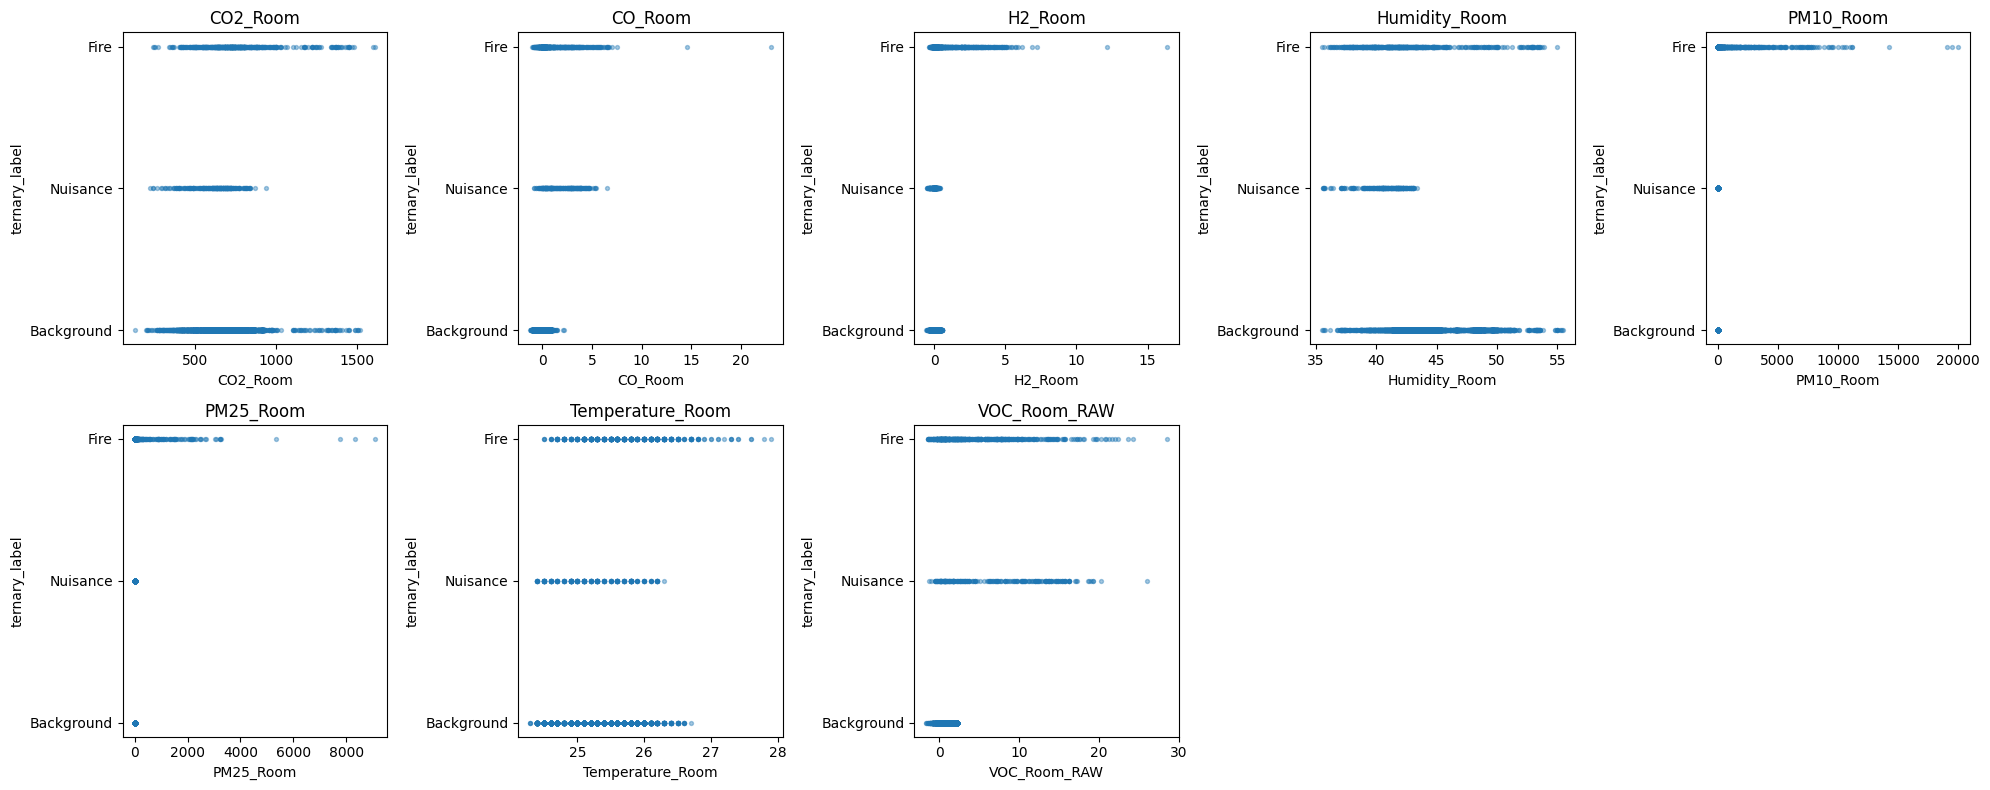

In [16]:
sample_df = fire_df.sample(5000, random_state=42)

plt.figure(figsize=(20, 8))

for i, feature in enumerate(sample_df.columns[:-1]):
    plt.subplot(2, 5, i+1)
    plt.scatter(sample_df[feature], sample_df['ternary_label'], s=8, alpha=0.4)
    plt.title(feature)
    plt.xlabel(feature)
    plt.ylabel('ternary_label')

plt.tight_layout()
plt.show()

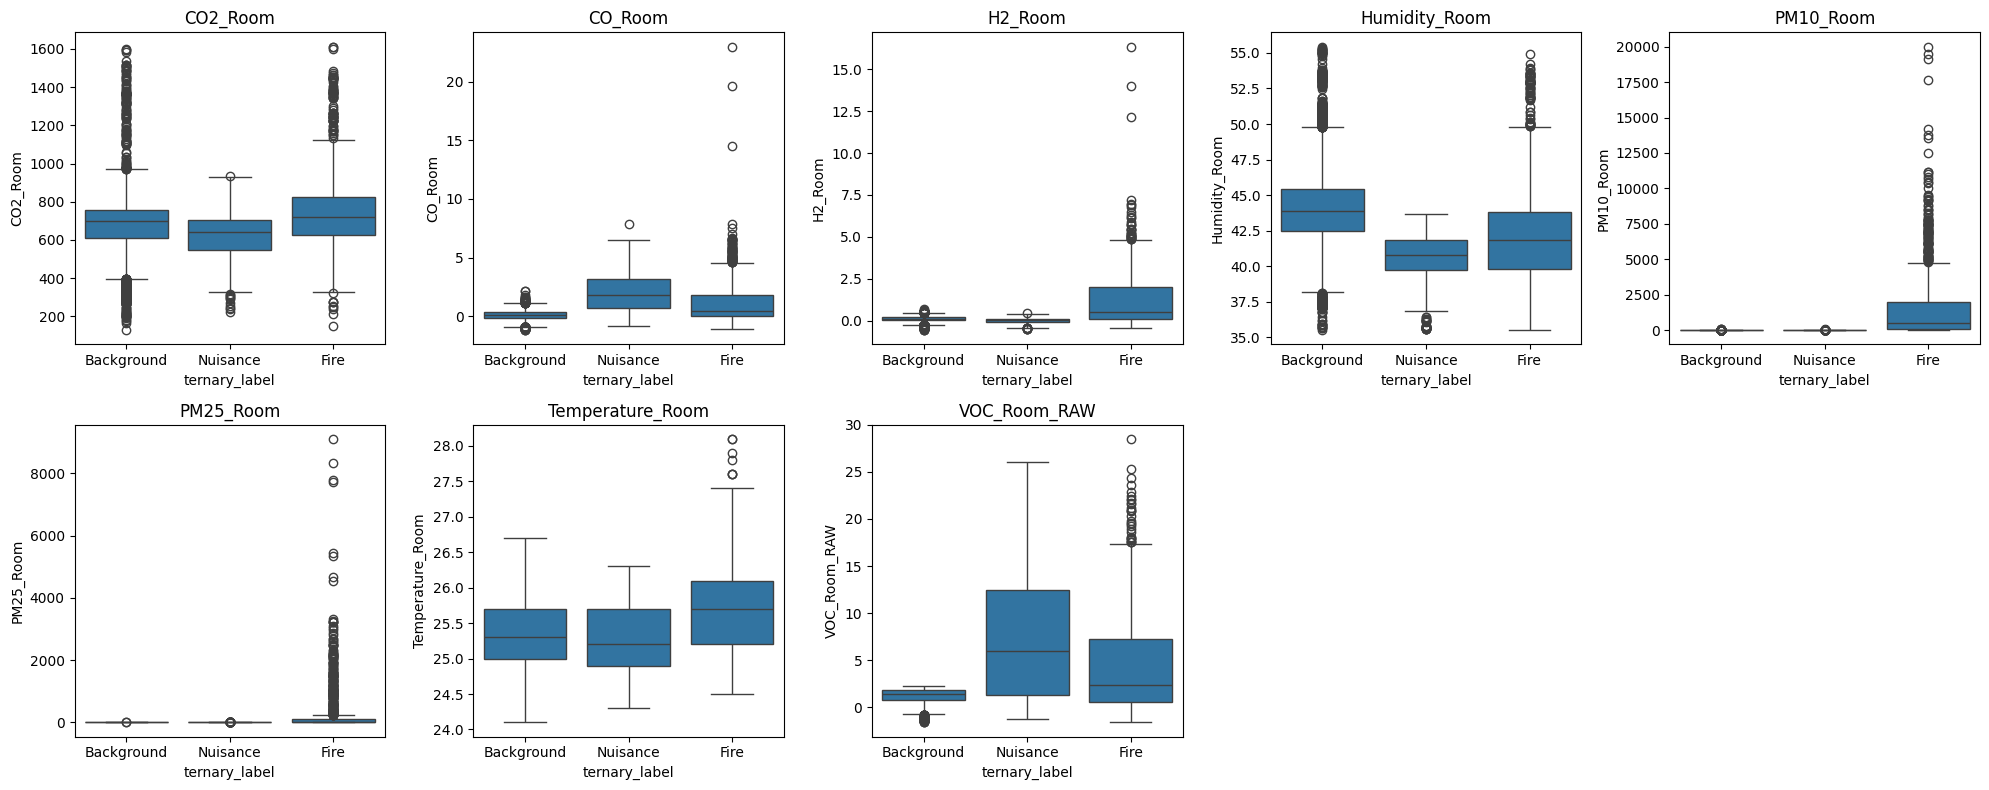

In [17]:
plt.figure(figsize=(20, 8))

for i, feature in enumerate(fire_df.columns[:-1]):
    plt.subplot(2, 5, i+1)
    sns.boxplot(data=fire_df.sample(10000, random_state=42), x='ternary_label', y=feature)
    plt.title(feature)

plt.tight_layout()
plt.show()

In [18]:
le = LabelEncoder()
fire_df["ternary_label"] = le.fit_transform(fire_df["ternary_label"])
#fire_df["anomaly_label"] = le.fit_transform(fire_df["anomaly_label"])

fire_df["ternary_label"].unique()

array([0, 1, 2])

In [19]:
print(le.classes_)

['Background' 'Fire' 'Nuisance']


In [20]:
#fire_df["anomaly_label"].unique()

In [21]:
fire_df.head()

,CO2_Room,CO_Room,H2_Room,Humidity_Room,PM10_Room,PM25_Room,Temperature_Room,VOC_Room_RAW,ternary_label
0,1150.0,-0.43,0.13,51.50,2.0,0.0,26.3,0.5,0
1,1300.0,-0.08,0.12,52.85,0.0,0.0,25.7,0.5,0
2,412.0,-0.08,0.22,50.60,2.0,0.0,26.5,0.5,0
3,1100.0,-0.16,0.13,52.66,1.0,0.0,25.9,0.6,0
4,1392.0,0.18,0.09,52.53,1.0,0.0,26.0,0.5,0


In [22]:
X = fire_df.drop('ternary_label', axis=1).values
y = fire_df['ternary_label'].values

In [23]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y,random_state=42, )
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, stratify=y_train, random_state=42)

In [24]:
# scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

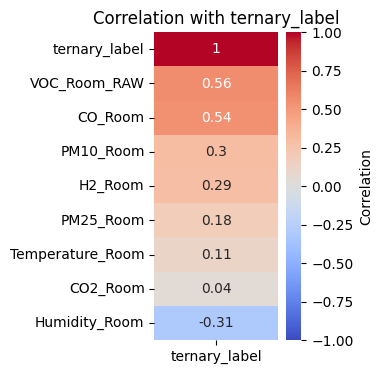

In [25]:
# Examining the relationships between features
correlation_matrix = fire_df.corr().round(2)

fire_alarm_corr = correlation_matrix[['ternary_label']].sort_values(by='ternary_label', ascending=False)

plt.figure(figsize=(2, 4))
sns.heatmap(data=fire_alarm_corr, annot=True, vmin=-1, vmax=1, cmap='coolwarm', cbar_kws={'label': 'Correlation'})
plt.title("Correlation with ternary_label")
plt.show()

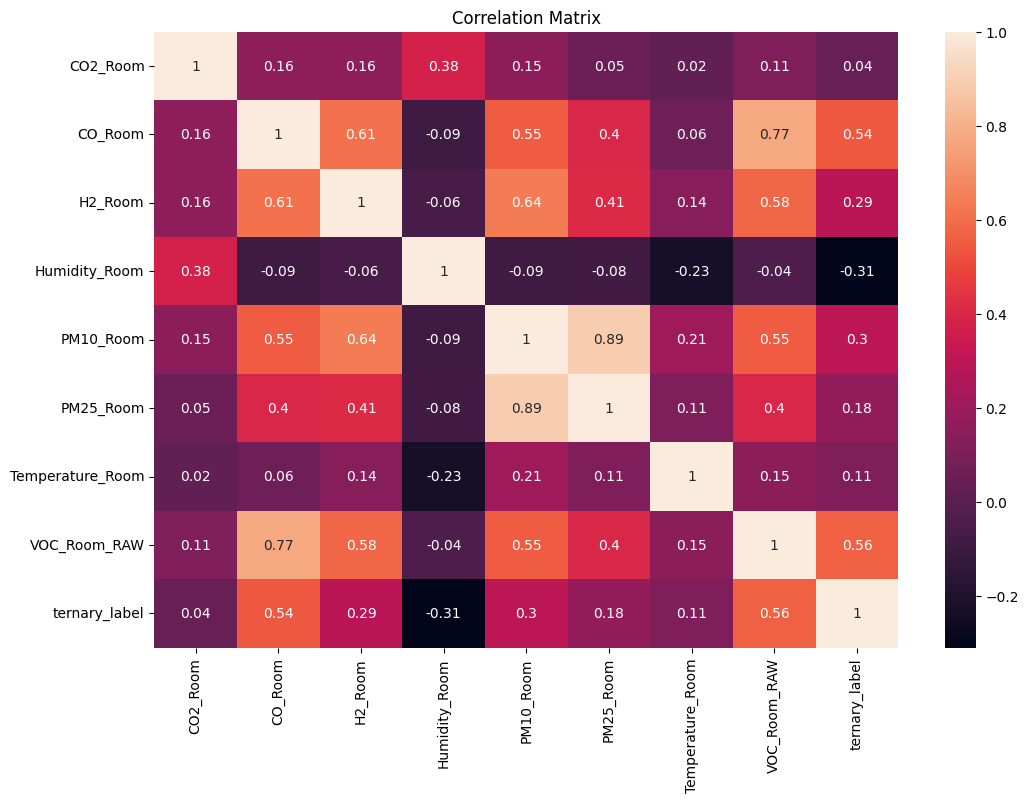

In [26]:
correlation_matrix = fire_df.corr().round(2)
plt.figure(figsize=(12, 8))
sns.heatmap(data=correlation_matrix, annot=True)
plt.title("Correlation Matrix")
plt.show()

In [27]:
model = LogisticRegression(solver='lbfgs', max_iter=1000)
model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000)

In [28]:
y_val_pred = model.predict(X_val_scaled)

In [29]:
print(classification_report(y_val, y_val_pred))

              precision    recall  f1-score   support

           0       0.95      1.00      0.97     40533
           1       1.00      0.75      0.86      6104
           2       0.92      0.73      0.81      2212

    accuracy                           0.95     48849
   macro avg       0.96      0.83      0.88     48849
weighted avg       0.96      0.95      0.95     48849



In [30]:
y_pred = model.predict(X_test_scaled)

In [31]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.95      1.00      0.98     50665
           1       1.00      0.76      0.86      7630
           2       0.93      0.74      0.82      2766

    accuracy                           0.96     61061
   macro avg       0.96      0.83      0.89     61061
weighted avg       0.96      0.96      0.95     61061



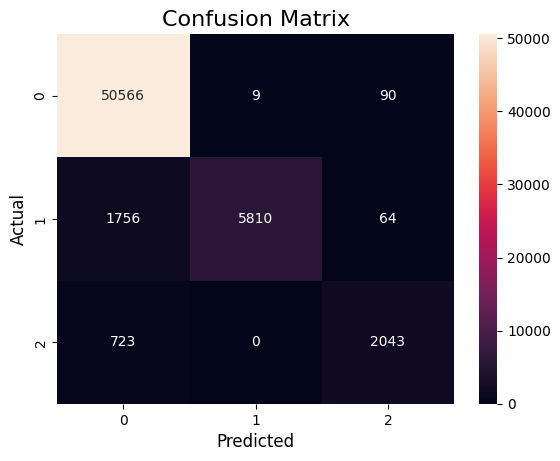

In [32]:
#cm = confusion_matrix(y_test, y_pred)
#sns.heatmap(cm, annot=True, fmt='d')
#, cmap='YlGnBu', xticklabels=iris.target_names, yticklabels=iris.target_names

# Create a confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot the confusion matrix
sns.heatmap(cm, annot=True,fmt='d')
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.title('Confusion Matrix',fontsize=16)
plt.show()

In [33]:
"""
sample = X_test[0].reshape(1, -1)
sample_scaled = scaler.transform(sample)

sensor_pred = model.predict(sample_scaled)
sensor_pred_label = le.inverse_transform(sensor_pred)[0]

true_label = le.inverse_transform([y_test[0]])[0]

print("Predicted label:", sensor_pred_label)
print("True label:", y_test[0], " ---> ", true_label)
"""

'\nsample = X_test[0].reshape(1, -1)\nsample_scaled = scaler.transform(sample)\n\nsensor_pred = model.predict(sample_scaled)\nsensor_pred_label = le.inverse_transform(sensor_pred)[0]\n\ntrue_label = le.inverse_transform([y_test[0]])[0]\n\nprint("Predicted label:", sensor_pred_label)\nprint("True label:", y_test[0], " ---> ", true_label)\n'

In [34]:
def sensor_decision(sample):
    sample = sample.reshape(1, -1)
    sample_scaled = scaler.transform(sample)

    sensor_pred = model.predict(sample_scaled)
    sensor_pred_label = le.inverse_transform(sensor_pred)[0]
    return sensor_pred_label

In [35]:
true_label = le.inverse_transform([y_test[0]])[0]

print("Predicted label:", sensor_decision(X_test[0]))
print("True label:", y_test[0], " ---> ", true_label)

Predicted label: Background
True label: 0  --->  Background


In [36]:
# Save the model
import joblib


# Save the model as a pickle in a file
joblib.dump(model, '/content/drive/MyDrive/Colab Notebooks/Multimodal - G. Project/ml_lr_classifier.pkl')
joblib.dump(scaler, '/content/drive/MyDrive/Colab Notebooks/Multimodal - G. Project/ml_lrـscaler.pkl')
joblib.dump(le, '/content/drive/MyDrive/Colab Notebooks/Multimodal - G. Project/ml_lrـlabel_encoder.pkl')

['/content/drive/MyDrive/Colab Notebooks/Multimodal - G. Project/ml_lrـlabel_encoder.pkl']

In [37]:
np.save("/content/drive/MyDrive/Colab Notebooks/Multimodal - G. Project/sample_sensor.npy", X_test[0])

In [38]:
import os

print(os.listdir('/content/drive/MyDrive/Colab Notebooks/Multimodal - G. Project'))

['Indoor Fire Dataset with Distributed Multi-Sensor Nodes.csv', 'Indoor Fire Smoke', 'yolo_models', 'yolo_predictions', 'ml_lr_classifier.pkl', 'ml_lrـscaler.pkl', 'ml_lrـlabel_encoder.pkl', 'sample_sensor.npy', 'ML fire Classification.ipynb', 'multimodal_fusion_ML_YOLO.ipynb', 'test_videos_fire_detection', 'yolov8n_results_summary.txt', 'results_test_video', 'gp-fire (2).ipynb']
